EDA

Setup

In [1]:
import datetime

import matplotlib.pyplot as plt
import polars as pl

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
CATEGORICAL = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, "#008300", "#4a3aa7", "#e34948"]

tx = pl.read_parquet("data/processed/transactions_train.parquet")
articles = pl.read_parquet("data/processed/articles.parquet")
customers = pl.read_parquet("data/processed/customers.parquet")
total_purchases = tx.height

Per-customer transaction count distribution

In [2]:
per_customer = tx.group_by("customer_id").agg(pl.len().alias("n_purchases"))
per_customer.select(
    pl.col("n_purchases").min().alias("min"),
    pl.col("n_purchases").quantile(0.25).alias("p25"),
    pl.col("n_purchases").median().alias("median"),
    pl.col("n_purchases").mean().alias("mean"),
    pl.col("n_purchases").quantile(0.75).alias("p75"),
    pl.col("n_purchases").quantile(0.90).alias("p90"),
    pl.col("n_purchases").quantile(0.99).alias("p99"),
    pl.col("n_purchases").max().alias("max"),
)

min,p25,median,mean,p75,p90,p99,max
u32,f64,f64,f64,f64,f64,f64,u32
1,3.0,9.0,23.334631,27.0,60.0,187.0,1895


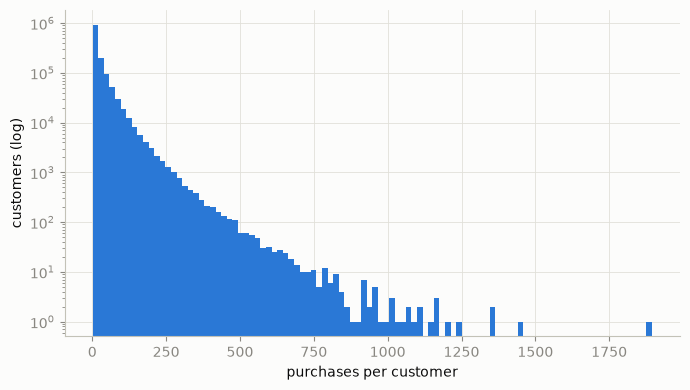

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(per_customer["n_purchases"], bins=100, color=BLUE, edgecolor="none")
ax.set_yscale("log")
ax.set_xlabel("purchases per customer")
ax.set_ylabel("customers (log)")
fig.tight_layout()

Per-article purchase count distribution

In [4]:
per_article = tx.group_by("article_id").agg(pl.len().alias("n_purchases"))
per_article.select(
    pl.col("n_purchases").min().alias("min"),
    pl.col("n_purchases").quantile(0.25).alias("p25"),
    pl.col("n_purchases").median().alias("median"),
    pl.col("n_purchases").mean().alias("mean"),
    pl.col("n_purchases").quantile(0.75).alias("p75"),
    pl.col("n_purchases").quantile(0.90).alias("p90"),
    pl.col("n_purchases").quantile(0.99).alias("p99"),
    pl.col("n_purchases").max().alias("max"),
)

min,p25,median,mean,p75,p90,p99,max
u32,f64,f64,f64,f64,f64,f64,u32
1,14.0,65.0,304.057735,286.0,793.0,3186.0,50287


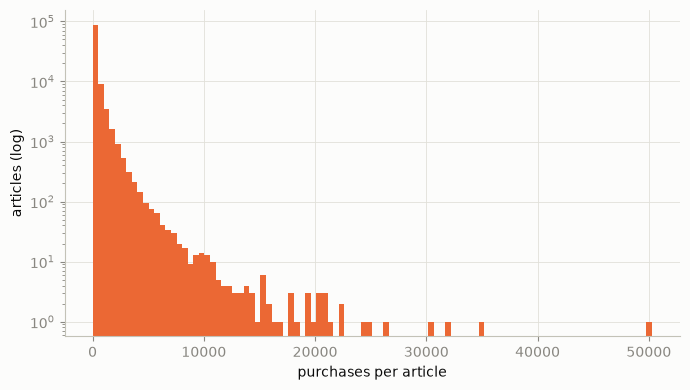

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(per_article["n_purchases"], bins=100, color=ORANGE, edgecolor="none")
ax.set_yscale("log")
ax.set_xlabel("purchases per article")
ax.set_ylabel("articles (log)")
fig.tight_layout()

Long tail of purchase concentration

In [6]:
def top_share(df, pct):
    n = max(1, round(df.height * pct))
    top_sum = df.sort("n_purchases", descending=True).head(n)["n_purchases"].sum()
    return top_sum / total_purchases

pl.DataFrame(
    [
        {
            "slice": label,
            "articles": round(per_article.height * pct),
            "share_of_total_purchases": top_share(per_article, pct),
        }
        for pct, label in [(0.01, "top 1%"), (0.05, "top 5%"), (0.10, "top 10%")]
    ]
)

slice,articles,share_of_total_purchases
str,i64,f64
"""top 1%""",1045,0.186151
"""top 5%""",5227,0.440447
"""top 10%""",10455,0.607512


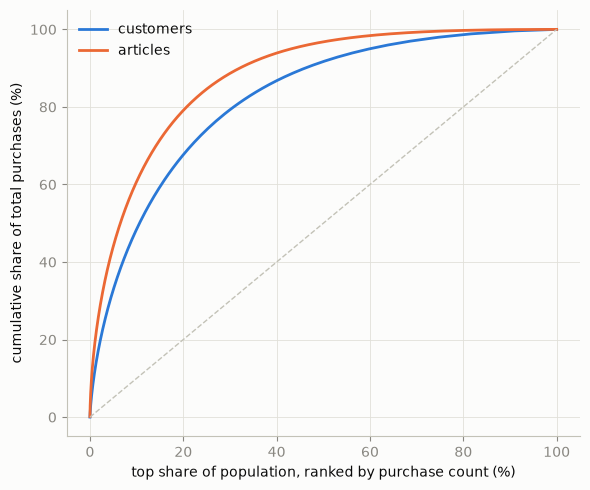

In [7]:
def cumulative_curve(df):
    s = df.sort("n_purchases", descending=True)["n_purchases"].to_numpy()
    cum = s.cumsum() / s.sum()
    x = (pl.Series(range(1, len(s) + 1)).to_numpy()) / len(s)
    return x, cum

cx, cy = cumulative_curve(per_customer)
ax_x, ay = cumulative_curve(per_article)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(cx * 100, cy * 100, color=BLUE, linewidth=2, label="customers")
ax.plot(ax_x * 100, ay * 100, color=ORANGE, linewidth=2, label="articles")
ax.plot([0, 100], [0, 100], color="#c3c2b7", linewidth=1, linestyle="--")
ax.set_xlabel("top share of population, ranked by purchase count (%)")
ax.set_ylabel("cumulative share of total purchases (%)")
ax.legend(frameon=False)
fig.tight_layout()

Purchase volume over time by week

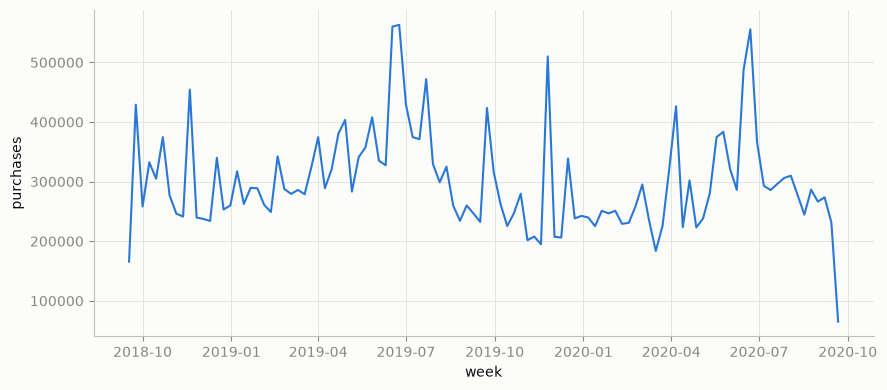

In [8]:
weekly_volume = (
    tx.with_columns(pl.col("t_dat").dt.truncate("1w").alias("week"))
    .group_by("week")
    .agg(pl.len().alias("purchases"))
    .sort("week")
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(weekly_volume["week"], weekly_volume["purchases"], color=BLUE, linewidth=1.5)
ax.set_xlabel("week")
ax.set_ylabel("purchases")
fig.tight_layout()

Repurchase rate

0.14099154771418587

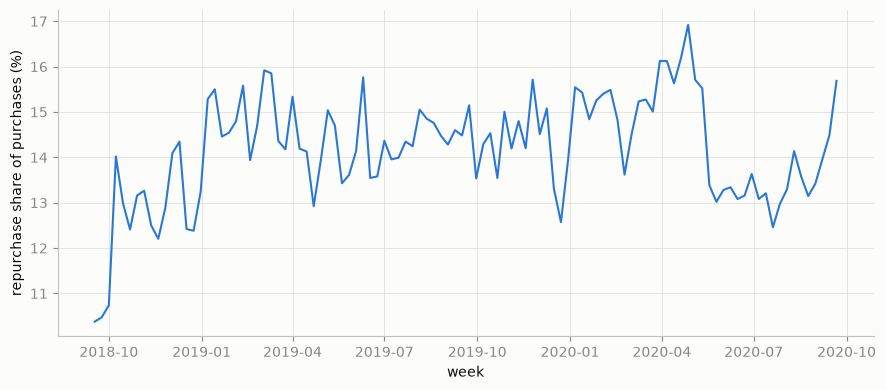

In [9]:
tx_sorted = tx.sort(["customer_id", "article_id", "t_dat"])
tx_sorted = tx_sorted.with_columns(
    pl.int_range(pl.len()).over(["customer_id", "article_id"]).alias("_occurrence")
)
tx_sorted = tx_sorted.with_columns((pl.col("_occurrence") > 0).alias("is_repurchase"))
weekly_repurchase = (
    tx_sorted.with_columns(pl.col("t_dat").dt.truncate("1w").alias("week"))
    .group_by("week")
    .agg([pl.len().alias("purchases"), pl.col("is_repurchase").sum().alias("repurchases")])
    .with_columns((pl.col("repurchases") / pl.col("purchases")).alias("repurchase_rate"))
    .sort("week")
)

overall_rate = tx_sorted["is_repurchase"].sum() / tx_sorted.height

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(weekly_repurchase["week"], weekly_repurchase["repurchase_rate"] * 100, color=BLUE, linewidth=1.5)
ax.set_xlabel("week")
ax.set_ylabel("repurchase share of purchases (%)")
fig.tight_layout()

overall_rate

Customer coverage by recency bucket

In [10]:
anchor = datetime.date(2020, 9, 22)
last_purchase = tx.group_by("customer_id").agg(pl.col("t_dat").max().alias("last_t_dat"))
cust_recency = customers.select("customer_id").join(last_purchase, on="customer_id", how="left")
cust_recency = cust_recency.with_columns(
    (pl.lit(anchor) - pl.col("last_t_dat")).dt.total_days().alias("days_since_last")
)

bucket_expr = (
    pl.when(pl.col("days_since_last").is_null()).then(pl.lit("never"))
    .when(pl.col("days_since_last") <= 7).then(pl.lit("last 1 week"))
    .when(pl.col("days_since_last") <= 28).then(pl.lit("last 4 weeks"))
    .when(pl.col("days_since_last") <= 84).then(pl.lit("last 12 weeks"))
    .when(pl.col("days_since_last") <= 364).then(pl.lit("last 52 weeks"))
    .otherwise(pl.lit("more than 52 weeks ago"))
)
cust_recency = cust_recency.with_columns(bucket_expr.alias("recency_bucket"))

order = ["last 1 week", "last 4 weeks", "last 12 weeks", "last 52 weeks", "more than 52 weeks ago", "never"]
bucket_counts = (
    cust_recency.group_by("recency_bucket").agg(pl.len().alias("customers"))
    .with_columns((pl.col("customers") / customers.height * 100).alias("share_pct"))
)
bucket_counts = bucket_counts.with_columns(
    pl.col("recency_bucket").map_elements(lambda b: order.index(b), return_dtype=pl.Int64).alias("_order")
).sort("_order")
bucket_counts.select("recency_bucket", "customers", "share_pct")

recency_bucket,customers,share_pct
str,u32,f64
"""last 1 week""",75481,5.501611
"""last 4 weeks""",164489,11.989169
"""last 12 weeks""",254162,18.525197
"""last 52 weeks""",499360,36.397032
"""more than 52 weeks ago""",368789,26.880057
"""never""",9699,0.706935


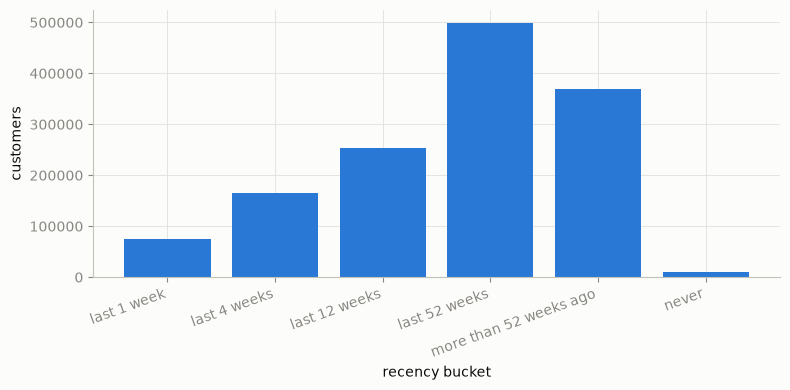

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(bucket_counts["recency_bucket"], bucket_counts["customers"], color=BLUE)
ax.set_xlabel("recency bucket")
ax.set_ylabel("customers")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()

Recency, cumulative

In [12]:
rows = []
for weeks in [1, 4, 12, 52]:
    days = weeks * 7
    n = cust_recency.filter(pl.col("days_since_last").is_not_null() & (pl.col("days_since_last") <= days)).height
    rows.append({"within_weeks": f"within {weeks}wk", "customers": n, "share_pct": n / customers.height * 100})

beyond = customers.height - rows[-1]["customers"]
rows.append({"within_weeks": "beyond 52wk (incl. never)", "customers": beyond, "share_pct": beyond / customers.height * 100})
cumulative = pl.DataFrame(rows)
cumulative

within_weeks,customers,share_pct
str,i64,f64
"""within 1wk""",75481,5.501611
"""within 4wk""",239970,17.49078
"""within 12wk""",494132,36.015977
"""within 52wk""",993492,72.413009
"""beyond 52wk (incl. never)""",378488,27.586991


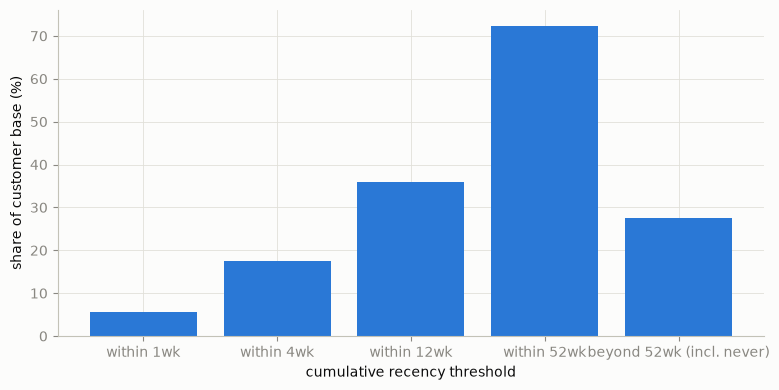

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cumulative["within_weeks"], cumulative["share_pct"], color=BLUE)
ax.set_xlabel("cumulative recency threshold")
ax.set_ylabel("share of customer base (%)")
fig.tight_layout()

Article lifecycle

In [14]:
lifecycle = tx.group_by("article_id").agg([
    pl.col("t_dat").min().alias("first_sale"),
    pl.col("t_dat").max().alias("last_sale"),
])
lifecycle = lifecycle.with_columns((pl.col("last_sale") - pl.col("first_sale")).dt.total_days().alias("span_days"))
lifecycle.select(
    pl.col("span_days").min().alias("min"),
    pl.col("span_days").quantile(0.25).alias("p25"),
    pl.col("span_days").median().alias("median"),
    pl.col("span_days").mean().alias("mean"),
    pl.col("span_days").quantile(0.75).alias("p75"),
    pl.col("span_days").max().alias("max"),
)

min,p25,median,mean,p75,max
i64,f64,f64,f64,f64,i64
0,85.0,205.0,241.021177,369.0,733


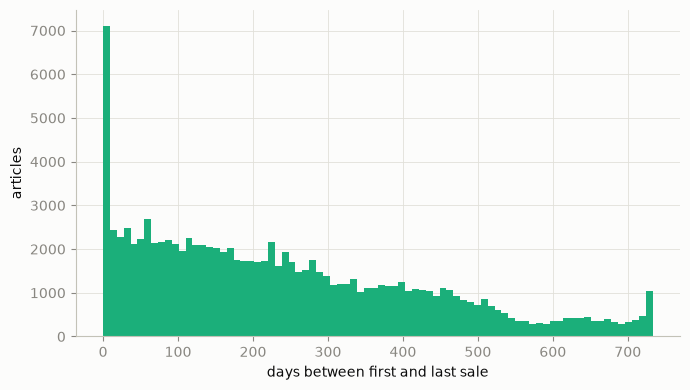

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(lifecycle["span_days"], bins=80, color=AQUA, edgecolor="none")
ax.set_xlabel("days between first and last sale")
ax.set_ylabel("articles")
fig.tight_layout()

In [16]:
val_start, val_end = datetime.date(2020, 9, 16), datetime.date(2020, 9, 22)
preceding_4wk_start = val_start - datetime.timedelta(weeks=4)
sold_in_val_week = tx.filter((pl.col("t_dat") >= val_start) & (pl.col("t_dat") <= val_end))["article_id"].unique()
new_articles = lifecycle.filter(
    pl.col("article_id").is_in(sold_in_val_week.to_list())
    & (pl.col("first_sale") >= preceding_4wk_start)
)
pl.DataFrame(
    {
        "measure": [
            "articles sold in validation week",
            f"of those, first sold within preceding 4 weeks ({preceding_4wk_start} to {val_end})",
        ],
        "articles": [len(sold_in_val_week), new_articles.height],
    }
)

measure,articles
str,i64
"""articles sold in validation we…",17986
"""of those, first sold within pr…",3432


Age distribution

In [17]:
age_null_rate = customers["age"].null_count() / customers.height
age_valid = customers.filter(pl.col("age").is_not_null())
age_valid.select(
    pl.col("age").min().alias("min"),
    pl.col("age").quantile(0.25).alias("p25"),
    pl.col("age").median().alias("median"),
    pl.col("age").mean().alias("mean"),
    pl.col("age").quantile(0.75).alias("p75"),
    pl.col("age").max().alias("max"),
    pl.lit(customers["age"].null_count()).alias("null_count"),
    pl.lit(age_null_rate).alias("null_rate"),
)

min,p25,median,mean,p75,max,null_count,null_rate
i64,f64,f64,f64,f64,i64,i32,f64
16,24.0,32.0,36.386965,49.0,99,15861,0.011561


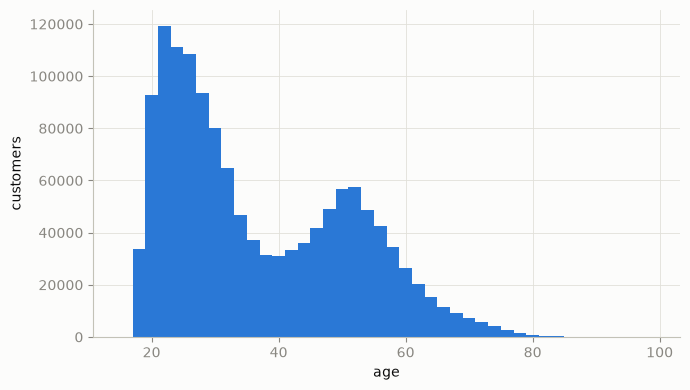

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(age_valid["age"], bins=range(15, 100, 2), color=BLUE, edgecolor="none")
ax.set_xlabel("age")
ax.set_ylabel("customers")
fig.tight_layout()

Purchase mix by index_group_name

In [19]:
mix = (
    tx.join(articles.select("article_id", "index_group_name"), on="article_id", how="left")
    .group_by("index_group_name")
    .agg(pl.len().alias("purchases"))
    .with_columns((pl.col("purchases") / total_purchases * 100).alias("share_pct"))
    .sort("purchases", descending=True)
)
mix

index_group_name,purchases,share_pct
str,u32,f64
"""Ladieswear""",20415260,64.222511
"""Divided""",7138254,22.455585
"""Menswear""",1771053,5.571395
"""Sport""",1246408,3.920962
"""Baby/Children""",1217349,3.829548


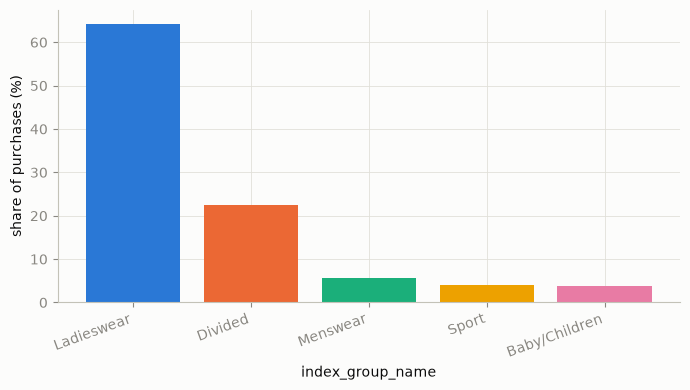

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = (CATEGORICAL * ((mix.height // len(CATEGORICAL)) + 1))[: mix.height]
ax.bar(mix["index_group_name"], mix["share_pct"], color=colors)
ax.set_xlabel("index_group_name")
ax.set_ylabel("share of purchases (%)")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()